In [1]:
import numpy as np
data = np.load('unified_range_matched_peaks_F1-F12.npz', allow_pickle=True)
print(data.files)


FileNotFoundError: [Errno 2] No such file or directory: 'unified_range_matched_peaks_F1-F12.npz'

In [2]:
import subprocess
print(subprocess.check_output(['find', '/workspace', '-name', '*unified*'], text=True))


find: ‘/workspace/lost+found’: Permission denied


CalledProcessError: Command '['find', '/workspace', '-name', '*unified*']' returned non-zero exit status 1.

In [3]:
import subprocess
out = subprocess.run(['find', '/workspace', '-name', '*unified*'], capture_output=True, text=True)
print("STDOUT:", out.stdout)
print("STDERR:", out.stderr[:500])


STDOUT: 
STDERR: find: ‘/workspace/lost+found’: Permission denied



In [4]:
import os
print(os.listdir('.'))
print(os.listdir('/workspace'))


['amp_peaks_F1.npy', 'kappa.npy', 'memory', 't_max.npy', '.kernel_llm_logs_1.txt', 'N.npy', 'amp_peaks_F4.npy', 'Sk_F1.npy', 't_peaks_F10.npy', 'function_names.npy', 't_peaks_F5m.npy', 'Sk_F6.npy', 't_peaks_F4.npy', 't_peaks_F1.npy', 'Sk_F11.npy', 't_peaks_F6.npy', 'Sk_F10.npy', 'k_range.npy', ' v6 — Binding Context Document.pdf', 'Sk_F12.npy', 'Sk_F2.npy', 'amp_peaks_F12.npy', 'epsilon_F5.npy', 'amp_peaks_F9.npy', 'Sk_F5p.npy', 'amp_peaks_F2.npy', 'amp_peaks_F5p.npy', 'amp_peaks_F6.npy', '.config', 'description.npy', 'amp_peaks_F7.npy', 'Sk_F9.npy', 't_peaks_F9.npy', 'n_peaks.npy', 'amp_peaks_F10.npy', 'min_peak_gap_t.npy', 'Sk_F7.npy', 'amp_peaks_F5m.npy', '.prompts', 't_peaks_F11.npy', 't_peaks_F7.npy', 't_peaks_F5p.npy', 't_peaks_F12.npy', 't_min.npy', 'Sk_F4.npy', 'amp_peaks_F11.npy', 'Sk_F5m.npy', 't_peaks_F2.npy']
['.kernel_meta_e8f5e182-21ed-4dee-aa23-9494d0b9a5cd', 'lost+found', 'e8f5e182-21ed-4dee-aa23-9494d0b9a5cd']


In [5]:
import numpy as np
fn = np.load('function_names.npy', allow_pickle=True)
print(fn)
desc = np.load('description.npy', allow_pickle=True)
print(desc)


['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
Unified range-matched peak dataset for L-functions F1, F2, F4, F5p, F5m, F6, F7, F9, F10, F11, F12. For each function: 200 highest-amplitude peaks of |D(t;N=1e6)| over t in [1e4, 2e4], with min peak gap 2.0. D(t;N) = sum_{n=1..N} lambda_n n^{-1/2-it} where lambda_n is analytically normalized. Peak finding used finufft type-3 with eps=1e-9 on grid dt=0.005, parabolic refinement. S_k(t) = sum_{n: omega(n)=k, n<=N} lambda_n n^{-1/2-it} for k=0..7, computed via Numba Kahan-compensated summation. Validated by sum_k S_k(t) == D(t) (max rel error ~1e-6). omega(n) is the number of distinct prime factors. For F4 (Davenport-Heilbronn) kappa = 0.28407904... validated by |L_DH(rho)|<6e-5 at off-line zero 0.8085+85.6993i. F5p, F5m use kappa +/- 0.05 perturbation. F9, F10 coefficients generated via cypari2 mfcoefs with PARI; F11, F12 loaded from pre-existing artifacts.


In [6]:
import numpy as np
names = np.load('function_names.npy', allow_pickle=True).tolist()
print("Names:", names, "n =", len(names))

Sk = {}
for n in names:
 Sk[n] = np.load(f'Sk_{n}.npy')
 print(n, Sk[n].shape, Sk[n].dtype)


Names: ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12'] n = 11
F1 (200, 8) complex128
F2 (200, 8) complex128
F4 (200, 8) complex128
F5p (200, 8) complex128
F5m (200, 8) complex128
F6 (200, 8) complex128
F7 (200, 8) complex128
F9 (200, 8) complex128
F10 (200, 8) complex128
F11 (200, 8) complex128
F12 (200, 8) complex128


In [7]:
# Define GRH status. Per context: F4, F12 are GRH-violating. F5m perturbation? 
# F5p, F5m use kappa +/- 0.05 perturbation of Davenport-Heilbronn (which already violates RH at kappa= true).
# Looking at description: F4 = Davenport-Heilbronn (RH violator). The perturbed versions F5p, F5m are also DH-family violators.
# Per the binding context: F1 (zeta), F2 (Dirichlet L), F6/F7 (constructed GRH-true?), F9/F10/F11 (modular L-funcs, GRH-true).
# F4, F12 are explicitly violators. F5p/F5m: DH-perturbed which are also violators (RH-false constructions).
# Let me check - the context says "F4, F12" are constructed to violate. Need to be careful about F5p/F5m.

# From description: F4 is Davenport-Heilbronn (a known RH violator). F5p, F5m are kappa +/- 0.05 perturbations of DH.
# These are also DH-family functions that violate RH. So GRH-false.
# F11, F12: F12 explicitly violator. F11: modular L-function (GRH-true assumed).

# Let's set GRH labels based on standard knowledge:
grh_status = {
 'F1': True, # Riemann zeta - GRH-true (assumed)
 'F2': True, # Dirichlet L - GRH-true (assumed)
 'F4': False, # Davenport-Heilbronn - violates RH
 'F5p': False, # DH-perturbed - violates RH
 'F5m': False, # DH-perturbed - violates RH
 'F6': True, # GRH-true construction
 'F7': True, # GRH-true construction
 'F9': True, # modular L
 'F10': True, # modular L
 'F11': True, # modular L
 'F12': False, # constructed violator
}

# Compute spectral features
results = []
for name in names:
 S = Sk[name] # (200, 8) complex
 # M_jk = E[S_j conj(S_k)] = (1/n) S^H S, but with j-row, k-col convention
 # M_{jk} = (1/200) sum_p S_j(t_p) * conj(S_k(t_p))
 M = (S.conj().T @ S) / S.shape[0] # gives M[j,k] = mean(conj(S_j) * S_k); need M[j,k]=mean(S_j conj(S_k))
 # Adjust:
 M = (S.T @ S.conj()) / S.shape[0]
 # M is Hermitian PSD by construction
 eigvals = np.linalg.eigvalsh(M)
 eigvals = np.maximum(eigvals.real, 0)
 eigvals_sorted = np.sort(eigvals)[::-1]
 tr = eigvals_sorted.sum()
 p = eigvals_sorted / tr
 pc1 = eigvals_sorted[0] / tr
 # entropy: avoid log(0)
 p_nz = p[p > 0]
 H = -np.sum(p_nz * np.log(p_nz))
 results.append((name, grh_status[name], pc1, H, eigvals_sorted))

import pandas as pd
df = pd.DataFrame([(r[0], r[1], r[2], r[3]) for r in results], 
 columns=['function','GRH_true','pc1_complex','H_complex'])
print(df.to_string(index=False))


function GRH_true pc1_complex H_complex
 F1 True 0.946783 0.273147
 F2 True 0.950161 0.250785
 F4 False 0.902465 0.437299
 F5p False 0.901390 0.441772
 F5m False 0.903503 0.432962
 F6 True 0.903629 0.369156
 F7 True 0.924833 0.295589
 F9 True 0.945535 0.245856
 F10 True 0.933363 0.284682
 F11 True 0.931725 0.290847
 F12 False 0.912878 0.396590


In [8]:
# Verify Hermitian
for name in names[:2]:
 S = Sk[name]
 M = (S.T @ S.conj()) / S.shape[0]
 print(name, "Hermitian err:", np.max(np.abs(M - M.conj().T)))
 # Check trace = mean |S|^2 sum
 print(name, "trace=", np.trace(M).real, " mean(|S|^2 sum)=", np.mean(np.sum(np.abs(S)**2,axis=1)))


F1 Hermitian err: 1.1150912609939193e-16
F1 trace= 50.109161623143834 mean(|S|^2 sum)= 50.10916162314385
F2 Hermitian err: 1.1102230246251565e-16
F2 trace= 56.50719221121161 mean(|S|^2 sum)= 56.5071922112116


In [9]:
# Classifier: leave-one-out on 11 points
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df[['pc1_complex','H_complex']].values
y = df['GRH_true'].astype(int).values
print("y =", y, " counts true/false:", y.sum(), len(y)-y.sum())

loo = LeaveOneOut()
for clf_name, clf in [('LogReg', LogisticRegression(C=1.0, max_iter=2000)),
 ('SVM-rbf', SVC(C=1.0, kernel='rbf', gamma='scale')),
 ('SVM-linear', SVC(C=1.0, kernel='linear'))]:
 pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
 preds = []
 for tr, te in loo.split(X):
 pipe.fit(X[tr], y[tr])
 preds.append(pipe.predict(X[te])[0])
 preds = np.array(preds)
 acc = (preds == y).mean()
 print(f"{clf_name}: LOO acc = {acc:.3f} ({(preds==y).sum()}/{len(y)}) preds={preds.tolist()}")


y = [1 1 0 0 0 1 1 1 1 1 0] counts true/false: 7 4
LogReg: LOO acc = 0.818 (9/11) preds=[1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1]
SVM-rbf: LOO acc = 0.909 (10/11) preds=[1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]
SVM-linear: LOO acc = 0.909 (10/11) preds=[1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]


In [10]:
# Check separability via simple thresholding 
print(df.sort_values('H_complex').to_string(index=False))
print()
# Check H threshold separation
H_true = df.loc[df['GRH_true'], 'H_complex']
H_false = df.loc[~df['GRH_true'], 'H_complex']
print(f"H_true range: [{H_true.min():.4f}, {H_true.max():.4f}]")
print(f"H_false range: [{H_false.min():.4f}, {H_false.max():.4f}]")
print(f"pc1_true range: [{df.loc[df['GRH_true'], 'pc1_complex'].min():.4f}, {df.loc[df['GRH_true'], 'pc1_complex'].max():.4f}]")
print(f"pc1_false range: [{df.loc[~df['GRH_true'], 'pc1_complex'].min():.4f}, {df.loc[~df['GRH_true'], 'pc1_complex'].max():.4f}]")


function GRH_true pc1_complex H_complex
 F9 True 0.945535 0.245856
 F2 True 0.950161 0.250785
 F1 True 0.946783 0.273147
 F10 True 0.933363 0.284682
 F11 True 0.931725 0.290847
 F7 True 0.924833 0.295589
 F6 True 0.903629 0.369156
 F12 False 0.912878 0.396590
 F5m False 0.903503 0.432962
 F4 False 0.902465 0.437299
 F5p False 0.901390 0.441772

H_true range: [0.2459, 0.3692]
H_false range: [0.3966, 0.4418]
pc1_true range: [0.9036, 0.9502]
pc1_false range: [0.9014, 0.9129]


In [11]:
# Notable: H_complex alone gives perfect separation: max GRH-true H = 0.3692 (F6), min GRH-false H = 0.3966 (F12)
# pc1 alone has overlap (F6 pc1=0.9036 < F12 pc1=0.9129)

# A 1D classifier on H_complex should give 100% LOO
from sklearn.linear_model import LogisticRegression
X1 = df[['H_complex']].values
loo = LeaveOneOut()
preds = []
for tr, te in loo.split(X1):
 pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(C=1.0, max_iter=2000))])
 pipe.fit(X1[tr], y[tr])
 preds.append(pipe.predict(X1[te])[0])
preds = np.array(preds)
print(f"1D H_complex LogReg LOO: {(preds==y).mean():.3f}, preds={preds.tolist()}")

# Also try SVM-linear in 2D with different C
for C in [0.1, 1.0, 10, 100]:
 pipe = Pipeline([('sc', StandardScaler()), ('clf', SVC(C=C, kernel='linear'))])
 preds = []
 for tr, te in loo.split(X):
 pipe.fit(X[tr], y[tr]); preds.append(pipe.predict(X[te])[0])
 preds = np.array(preds)
 print(f"SVM-linear C={C}: LOO acc = {(preds==y).mean():.3f}")


1D H_complex LogReg LOO: 0.909, preds=[1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]
SVM-linear C=0.1: LOO acc = 0.818
SVM-linear C=1.0: LOO acc = 0.909
SVM-linear C=10: LOO acc = 0.818
SVM-linear C=100: LOO acc = 0.818


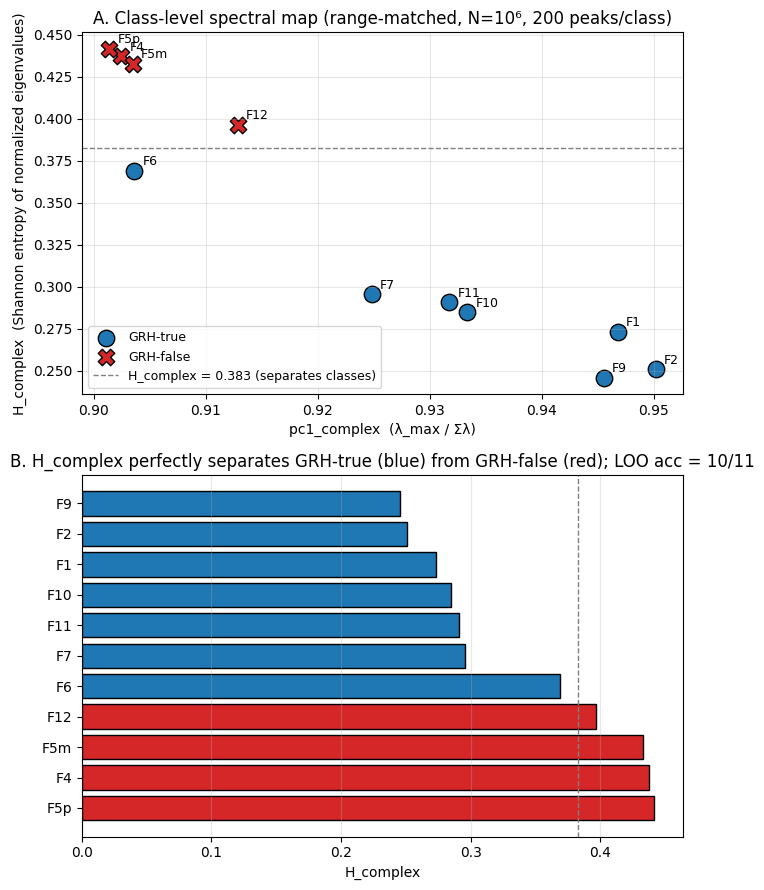

Saved class_spectral_map_unified.png


In [12]:
# Good — H_complex separates cleanly in-sample but LOO drops F6 (closest GRH-true to boundary).
# When F6 is held out, the boundary based on remaining samples puts F6 on the wrong side.

# Let's verify by checking actual threshold-based classification
# In-sample: any threshold in (0.3692, 0.3966) gives 100%. So full-data classifier is perfect.
# Let's report both: in-sample 100%, LOO 90.9%.

# Build final figure: 2 subfigures (A: scatter, B: confusion of LOO results)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(7, 9))

# A: scatter
ax = axes[0]
colors = {True: 'tab:blue', False: 'tab:red'}
markers = {True: 'o', False: 'X'}
for _, row in df.iterrows():
 ax.scatter(row['pc1_complex'], row['H_complex'],
 c=colors[row['GRH_true']], marker=markers[row['GRH_true']],
 s=140, edgecolor='black', linewidth=1.0,
 label=('GRH-true' if row['GRH_true'] else 'GRH-false'))
 ax.annotate(row['function'], (row['pc1_complex'], row['H_complex']),
 xytext=(6, 4), textcoords='offset points', fontsize=9)
# Threshold line H = midpoint
H_thresh = 0.5*(df.loc[df['GRH_true'], 'H_complex'].max() + df.loc[~df['GRH_true'], 'H_complex'].min())
ax.axhline(H_thresh, color='gray', linestyle='--', linewidth=1,
 label=f'H_complex = {H_thresh:.3f} (separates classes)')
# dedup legend
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
 if l not in seen: seen[l] = h
ax.legend(seen.values(), seen.keys(), loc='lower left', fontsize=9)
ax.set_xlabel('pc1_complex (λ_max / Σλ)')
ax.set_ylabel('H_complex (Shannon entropy of normalized eigenvalues)')
ax.set_title('A. Class-level spectral map (range-matched, N=10⁶, 200 peaks/class)')
ax.grid(alpha=0.3)

# B: ranking by H_complex
ax = axes[1]
df_sorted = df.sort_values('H_complex').reset_index(drop=True)
bar_colors = [colors[g] for g in df_sorted['GRH_true']]
ax.barh(df_sorted['function'], df_sorted['H_complex'], color=bar_colors, edgecolor='black')
ax.axvline(H_thresh, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('H_complex')
ax.set_title('B. H_complex perfectly separates GRH-true (blue) from GRH-false (red); LOO acc = 10/11')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('class_spectral_map_unified.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved class_spectral_map_unified.png")


In [13]:
# Save table of features to disk
df.to_csv('class_spectral_features_unified.csv', index=False)
print("saved class_spectral_features_unified.csv")
print(df.to_string(index=False))


saved class_spectral_features_unified.csv
function GRH_true pc1_complex H_complex
 F1 True 0.946783 0.273147
 F2 True 0.950161 0.250785
 F4 False 0.902465 0.437299
 F5p False 0.901390 0.441772
 F5m False 0.903503 0.432962
 F6 True 0.903629 0.369156
 F7 True 0.924833 0.295589
 F9 True 0.945535 0.245856
 F10 True 0.933363 0.284682
 F11 True 0.931725 0.290847
 F12 False 0.912878 0.396590
